In [1]:
!pip install kaggle

In [2]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"medjinaagarazor","key":"45daaaf603c4800496931f89efd6afdc"}'}

In [3]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [5]:
!kaggle datasets download -d tongpython/cat-and-dog #download and unzip the zip that has the database i'll use
!unzip -o cat-and-dog.zip -d ./data && find ./data -name ".DS_Store" -type f -delete


Streaming output truncated to the last 5000 lines.
  inflating: ./data/training_set/training_set/cats/cat.3704.jpg  
  inflating: ./data/training_set/training_set/cats/cat.3705.jpg  
  inflating: ./data/training_set/training_set/cats/cat.3706.jpg  
  inflating: ./data/training_set/training_set/cats/cat.3707.jpg  
  inflating: ./data/training_set/training_set/cats/cat.3708.jpg  
  inflating: ./data/training_set/training_set/cats/cat.3709.jpg  
  inflating: ./data/training_set/training_set/cats/cat.371.jpg  
  inflating: ./data/training_set/training_set/cats/cat.3710.jpg  
  inflating: ./data/training_set/training_set/cats/cat.3711.jpg  
  inflating: ./data/training_set/training_set/cats/cat.3712.jpg  
  inflating: ./data/training_set/training_set/cats/cat.3713.jpg  
  inflating: ./data/training_set/training_set/cats/cat.3714.jpg  
  inflating: ./data/training_set/training_set/cats/cat.3715.jpg  
  inflating: ./data/training_set/training_set/cats/cat.3716.jpg  
  inflating: ./data/traini

In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [8]:
NUM_CLASSES = 2 # two classes , dogs and cats
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.0005
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

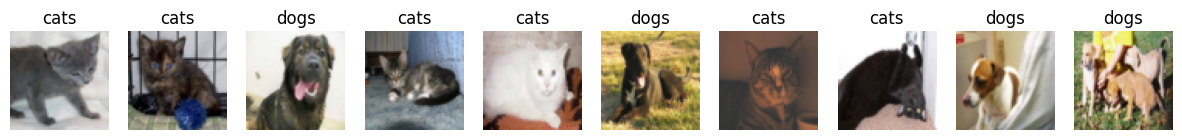

Labels of first 10 images: ['cats', 'cats', 'dogs', 'cats', 'cats', 'dogs', 'cats', 'cats', 'dogs', 'dogs']


In [9]:

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

# train my datasets, the database dog and cats is inside data
train_dataset = datasets.ImageFolder(root='data/training_set/training_set', transform=transform)
test_dataset  = datasets.ImageFolder(root='data/test_set/test_set', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


images, labels = next(iter(train_loader))
images = images.permute(0, 2, 3, 1).numpy()  # [B,H,W,C]
labels = labels.numpy()

# Denormalize images
images = images * 0.5 + 0.5  # keep float in [0,1] for plt.imshow

# let's display first 10 images
fig, axes = plt.subplots(1, 10, figsize=(15,3)) # a row of 10 images
for i in range(10):
    axes[i].imshow(images[i])
    axes[i].axis('off')
    axes[i].set_title(train_dataset.classes[labels[i]])
plt.show()

print("Labels of first 10 images:", [train_dataset.classes[l] for l in labels[:10]])


In [11]:
class BasicCNN(nn.Module): # simple cnn without batch and dropout
  def __init__(self, num_classes):
    super(BasicCNN, self).__init__()
    self.features = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1), #RGB, number of filters, size of each filter, moves 1 pixel, add one pixel
    nn.LeakyReLU(),
    nn.Conv2d(32, 32, kernel_size=3, stride=2, padding=1),
    nn.LeakyReLU(),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.LeakyReLU(),
    nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1),
    nn.LeakyReLU(),
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64*16*16, 128),
        nn.LeakyReLU(),
        nn.Linear(128, num_classes),

    )

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

model = BasicCNN(NUM_CLASSES).to(DEVICE)
print(model)

BasicCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.01)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): LeakyReLU(negative_slope=0.01)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): LeakyReLU(negative_slope=0.01)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [16]:
class Batch_CNN(nn.Module): #with batch for stability and dropout
  def __init__(self, num_classes):
    super(Batch_CNN, self).__init__()
    self.features = nn.Sequential(
    nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(32),
    nn.LeakyReLU(),
    nn.Conv2d(32, 32, kernel_size=3, stride=2, padding=1),
    nn.BatchNorm2d(32),
    nn.LeakyReLU(),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(),
    nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(),
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64 * 16 * 16, 128),
        nn.BatchNorm1d(128),
        nn.LeakyReLU(),
        nn.Dropout(0.5),
        nn.Linear(128, num_classes),
    )

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

model = Batch_CNN(NUM_CLASSES).to(DEVICE)
print(model)

Batch_CNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.01)
    (9): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): LeakyReLU(negative_slope=0.01)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=16384, out_features=128, bias=True)
    (2):

In [17]:
criterion = nn.CrossEntropyLoss() #  a loss function , optimizer is used to reduce loss
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

def train_model(model, optimizer, criterion, train_loader, test_loader, epochs):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')


        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        val_loss = val_loss / len(test_loader)
        val_acc = 100 * val_correct / val_total
        print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.2f}%')
        model.train()


In [18]:
def evaluate_model(model, criterion, test_loader):
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    predictions = []
    actuals = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
            predictions.append(predicted.cpu().numpy())
            actuals.append(labels.cpu().numpy())


    test_loss = test_loss / len(test_loader)
    test_acc = 100 * test_correct / test_total
    print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%')

    return test_acc, np.concatenate(predictions), np.concatenate(actuals)



In [19]:

#to train both models and find the accuracy values of each, using epoch 10 because bigger the number epoch, the result is more accurate
basic_model = BasicCNN(NUM_CLASSES).to(DEVICE)
optimizer_basic = torch.optim.Adam(basic_model.parameters(), lr=LEARNING_RATE)
train_model(basic_model, optimizer_basic, criterion, train_loader, test_loader, EPOCHS)
basic_acc, preds_basic, actuals_basic = evaluate_model(basic_model, criterion, test_loader)

improved_model = Batch_CNN(NUM_CLASSES).to(DEVICE)
optimizer_improved = torch.optim.Adam(improved_model.parameters(), lr=LEARNING_RATE)
train_model(improved_model, optimizer_improved, criterion, train_loader, test_loader, EPOCHS)
improved_acc, preds_improved, actuals_improved = evaluate_model(improved_model, criterion, test_loader)


print(f"\nComparison:\nBasic CNN Accuracy: {basic_acc:.2f}%\nImproved CNN Accuracy: {improved_acc:.2f}%")


Epoch [1/10], Loss: 0.6535, Accuracy: 60.55%
Validation Loss: 0.6008, Validation Accuracy: 67.18%
Epoch [2/10], Loss: 0.5738, Accuracy: 69.89%
Validation Loss: 0.5690, Validation Accuracy: 70.29%
Epoch [3/10], Loss: 0.5245, Accuracy: 73.64%
Validation Loss: 0.5595, Validation Accuracy: 70.59%
Epoch [4/10], Loss: 0.4679, Accuracy: 76.89%
Validation Loss: 0.5532, Validation Accuracy: 73.80%
Epoch [5/10], Loss: 0.3926, Accuracy: 82.50%
Validation Loss: 0.5987, Validation Accuracy: 72.81%
Epoch [6/10], Loss: 0.2857, Accuracy: 87.91%
Validation Loss: 0.7458, Validation Accuracy: 72.52%
Epoch [7/10], Loss: 0.1690, Accuracy: 93.30%
Validation Loss: 0.7945, Validation Accuracy: 73.11%
Epoch [8/10], Loss: 0.0674, Accuracy: 97.94%
Validation Loss: 1.2867, Validation Accuracy: 72.86%
Epoch [9/10], Loss: 0.0342, Accuracy: 98.93%
Validation Loss: 1.4377, Validation Accuracy: 73.46%
Epoch [10/10], Loss: 0.0133, Accuracy: 99.61%
Validation Loss: 1.5571, Validation Accuracy: 73.60%
Test Loss: 1.5571, 

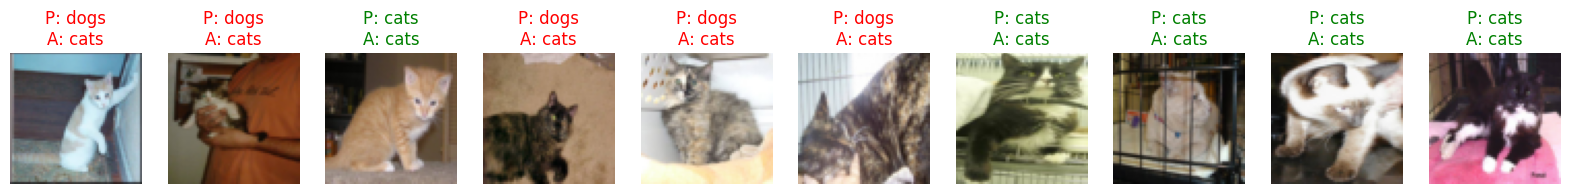

In [20]:
import matplotlib.pyplot as plt
import numpy as np


images, labels = next(iter(test_loader))
images, labels = images.to(DEVICE), labels.to(DEVICE)

#trying to get predictions from the improved model
improved_model.eval()
with torch.no_grad():
    outputs = improved_model(images)
    _, preds = torch.max(outputs, 1)

images = images.permute(0, 2, 3, 1).cpu().numpy() * 0.5 + 0.5  # denormalize images
labels = labels.cpu().numpy()
preds = preds.cpu().numpy()

# let's display predictions and results for the first 10 images
fig, axes = plt.subplots(1, 10, figsize=(20, 3)) # 1 row an 10 images
for i in range(10):
    axes[i].imshow(images[i])
    axes[i].axis('off')
    # color red  if wrong prediction and green if it's correct
    color = 'red' if preds[i] != labels[i] else 'green'
    axes[i].set_title(f"P: {train_dataset.classes[preds[i]]}\nA: {train_dataset.classes[labels[i]]}", color=color)
plt.show()
